In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings as wrn
wrn.filterwarnings('ignore')
import seaborn as sns
import statsmodels.api as sm
import statistics

In [ ]:
df = pd.read_excel('Data Science_P1.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
df.shape

(1200, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
OrderID,0.00
Date,0.00
CustomerID,0.00
Product,0.00
Quantity,0.00
UnitPrice,0.00
ShippingAddress,0.00
PaymentMethod,0.00
OrderStatus,0.00
TrackingNumber,0.00


In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558




*   The Couponcode is containing 25.75% Missing Values means some of the users are not using the coupon code, so instead of removing it replacing by using mode




In [ ]:
df['CouponCode'] = df['CouponCode'].fillna(df['CouponCode'].mode())
df.CouponCode.value_counts()

,count
CouponCode,
FREESHIP,313
WINTER15,292
SAVE10,286


Text(0.5, 1.02, 'CouponCode')

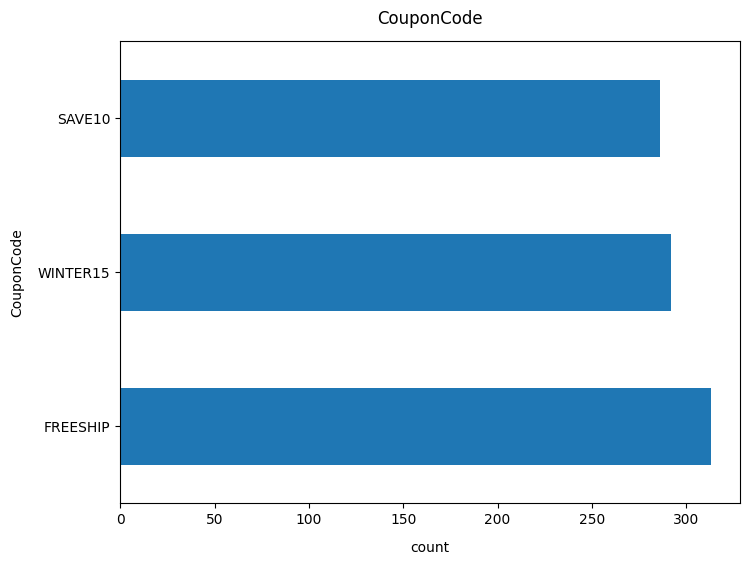

In [ ]:
df.CouponCode.value_counts().plot(kind ='barh',figsize=(8,6))
plt.xlabel('count', labelpad =10)
plt.ylabel('CouponCode', labelpad =10)
plt.title('CouponCode', y =1.02)

In [ ]:
from scipy.stats import zscore

In [ ]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [ ]:
numeric_col = ['Quantity','UnitPrice','TotalPrice']
z_score = df[numeric_col].apply(zscore)
z_score

,Quantity,UnitPrice,TotalPrice
0,1.459993,1.086822,2.195362
1,-0.672248,-1.040426,-0.916723
2,1.459993,0.985653,2.073705
3,-1.382995,-0.422247,-0.952732
4,0.749246,1.367855,1.769427
...,...,...,...
1195,-1.382995,-1.265242,-1.155474
1196,-0.672248,1.553146,0.330795
1197,-0.672248,0.408063,-0.219994
1198,0.749246,-0.476383,-0.004745


<Axes: >

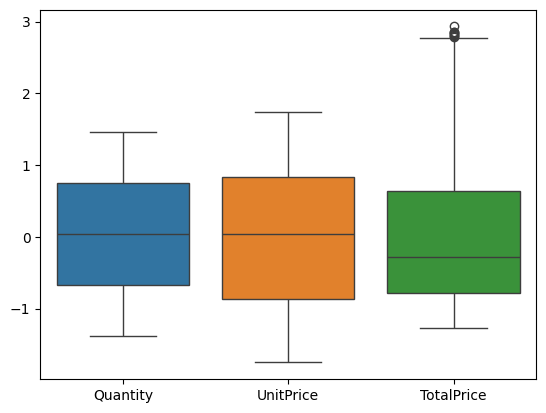

In [ ]:
sns.boxplot(data=z_score)

**Feature Engineer**

Feature 1 - Find the product Revenue for each product

In [ ]:
Product_Revenue = df.groupby('Product')['TotalPrice'].sum()
Product_Revenue

,TotalPrice
Product,
Chair,195620.11
Desk,167459.93
Laptop,192126.56
Monitor,175651.41
Phone,151722.39
Printer,195612.61
Tablet,186568.95


In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


**Feature 2- Find the High Vlaue Products**

In [ ]:
Threshold = df['UnitPrice'].quantile(0.75)

df['HighVlaueProduct'] = (df['UnitPrice']>=Threshold).astype(int)
df_product_high_value = pd.DataFrame({'Product': df['Product'], 'UnitPrice': df['UnitPrice'],'HighVlaueProduct': df['HighVlaueProduct']})
df_product_high_value

,Product,UnitPrice,HighVlaueProduct
0,Monitor,570.62,1
1,Phone,151.35,0
2,Tablet,550.68,1
3,Chair,273.19,0
4,Printer,626.01,1
...,...,...,...
1195,Desk,107.04,0
1196,Monitor,662.53,1
1197,Tablet,436.84,0
1198,Chair,262.52,0


In [ ]:
df["WeekendOrders"] = df["Date"].dt.dayofweek >= 5
df.WeekendOrders.value_counts()

,count
WeekendOrders,
False,842
True,358


In [ ]:
df["WeekdayOrders"] = df["Date"].dt.dayofweek <= 5
df.WeekdayOrders.value_counts()

,count
WeekdayOrders,
True,1014
False,186


**Feature-3**
Calculate the Average TotalPrice for weekdays and Weekendorders

In [ ]:
avg_totalprice_weekday = df[df["WeekdayOrders"]]['TotalPrice'].mean()
avg_totalprice_weekend = df[df["WeekendOrders"]]['TotalPrice'].mean()

print(f"Average TotalPrice for Weekday Orders: {avg_totalprice_weekday:.2f}")
print(f"Average TotalPrice for Weekend Orders: {avg_totalprice_weekend:.2f}")

Average TotalPrice for Weekday Orders: 1050.86
Average TotalPrice for Weekend Orders: 1024.55


**DATA VISUALIZATION**

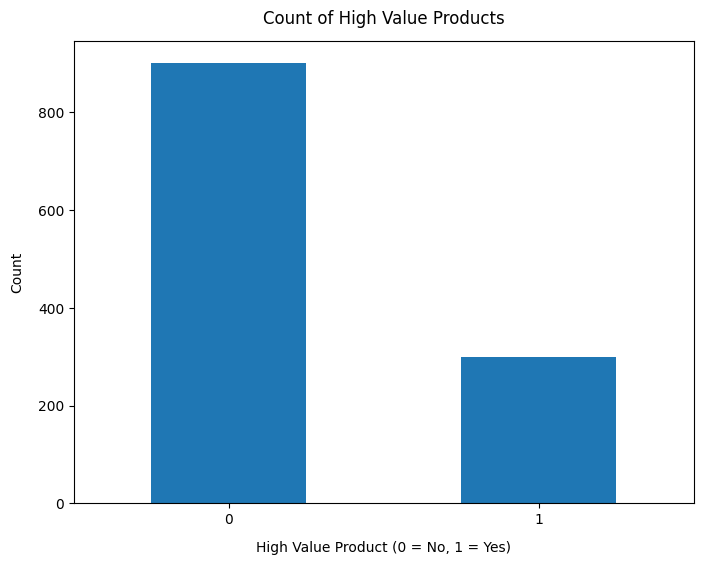

In [ ]:
df['HighVlaueProduct'].value_counts().plot(kind='bar', figsize=(8,6))
plt.xlabel('High Value Product (0 = No, 1 = Yes)', labelpad=10)
plt.ylabel('Count', labelpad=10)
plt.title('Count of High Value Products', y=1.02)
plt.xticks(rotation=0)
plt.show()

<Figure size 640x480 with 0 Axes>

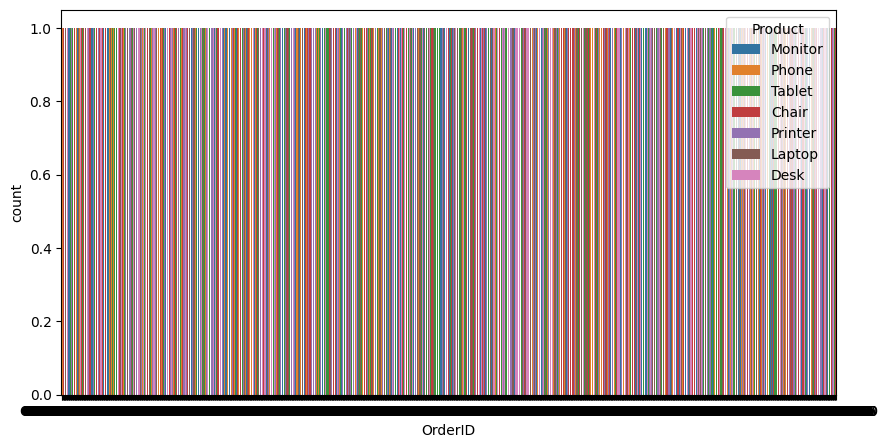

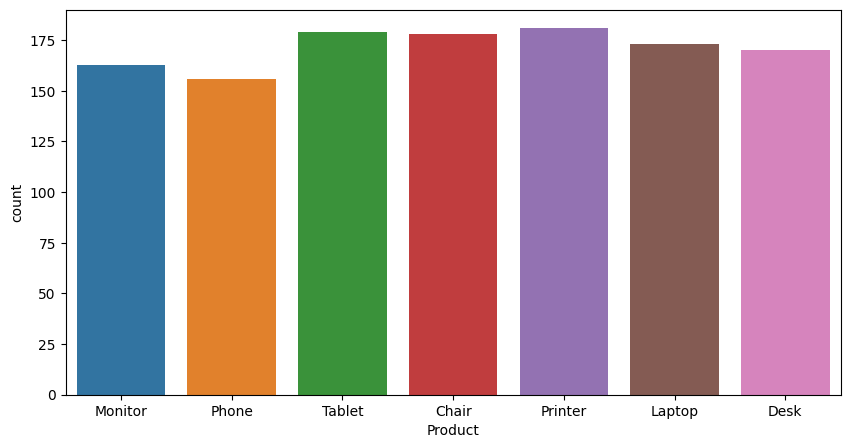

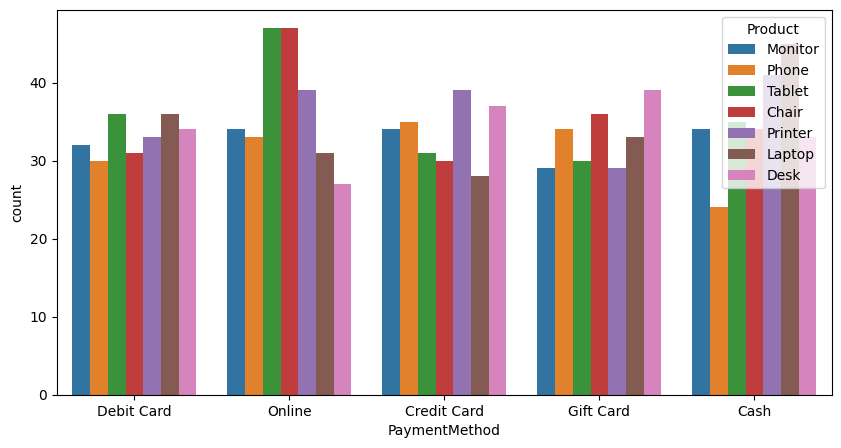

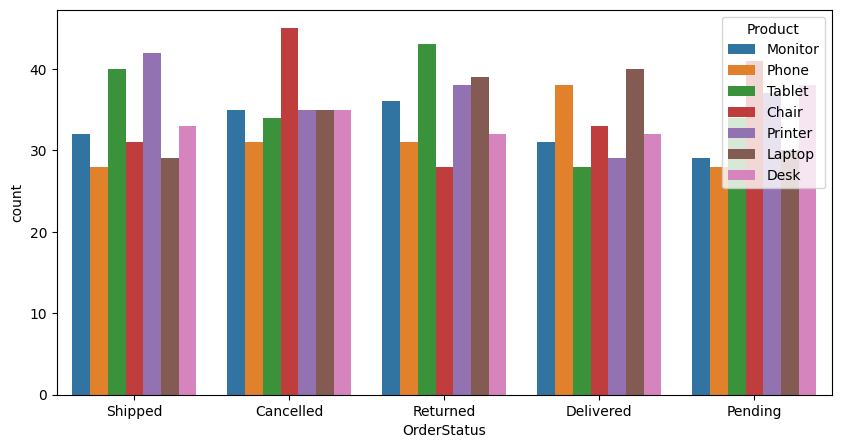

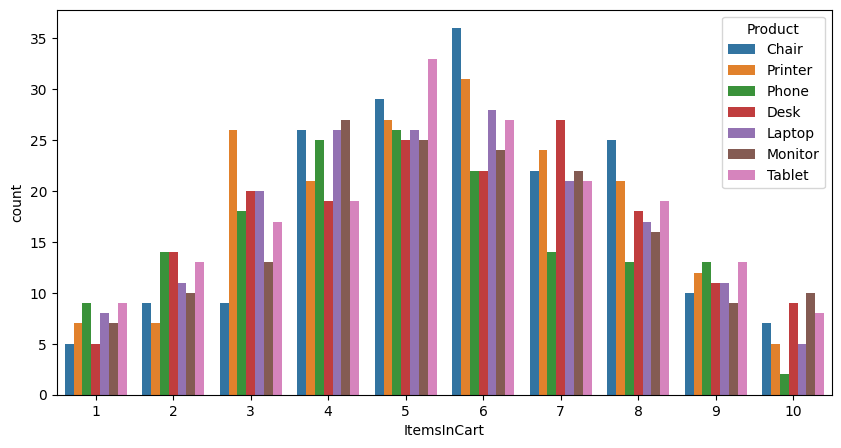

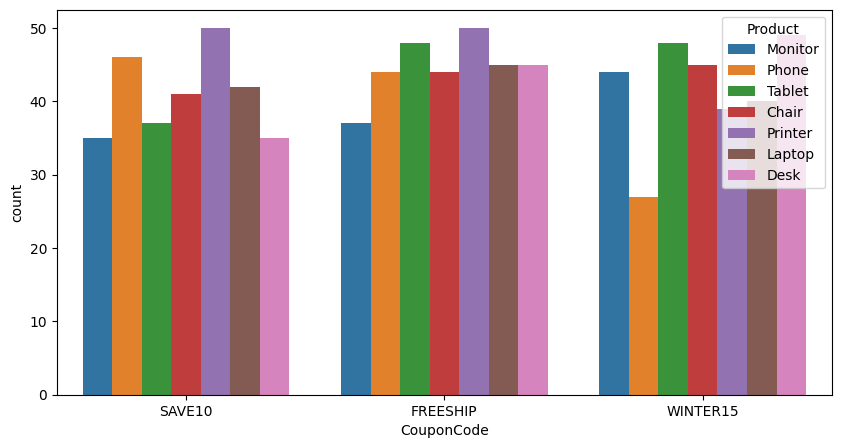

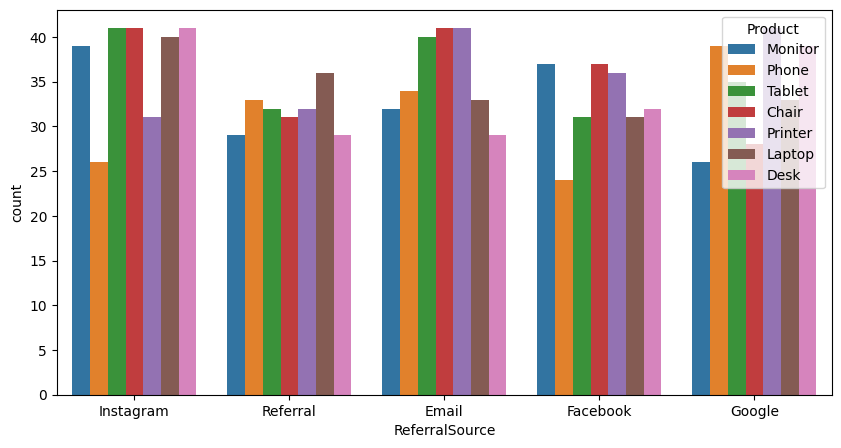

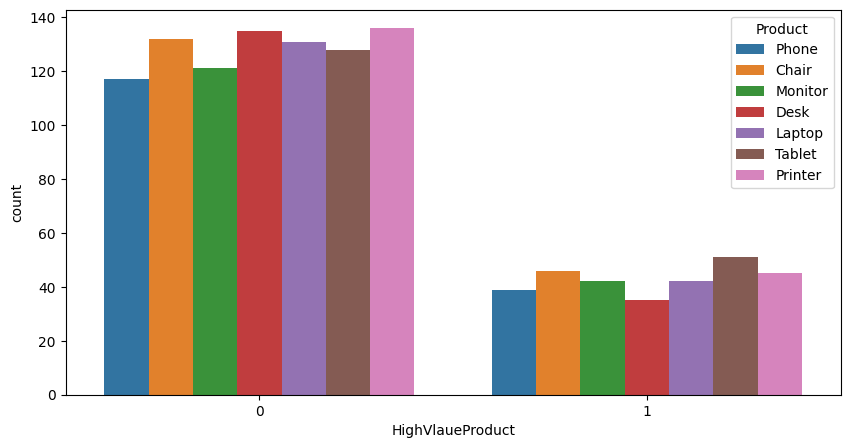

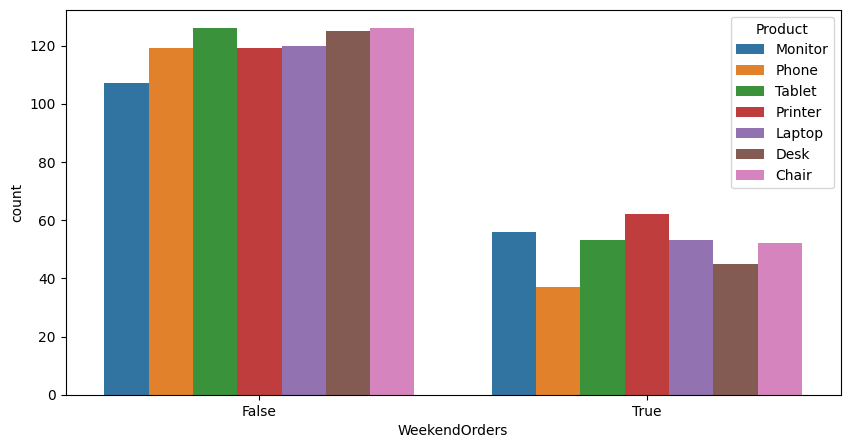

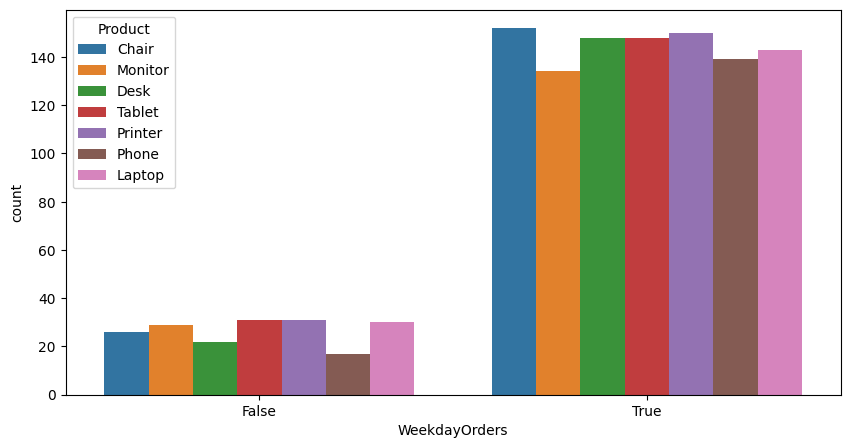

In [ ]:
columns_to_plot = df.drop(columns=['Date','CustomerID', 'TrackingNumber','ShippingAddress','UnitPrice', 'TotalPrice','Quantity'], axis=1).columns
for i, predictor in enumerate(columns_to_plot):
   plt.figure(i)
   plt.figure(figsize=(10,5))
   sns.countplot(data=df,x=predictor, hue = 'Product')


<Axes: >

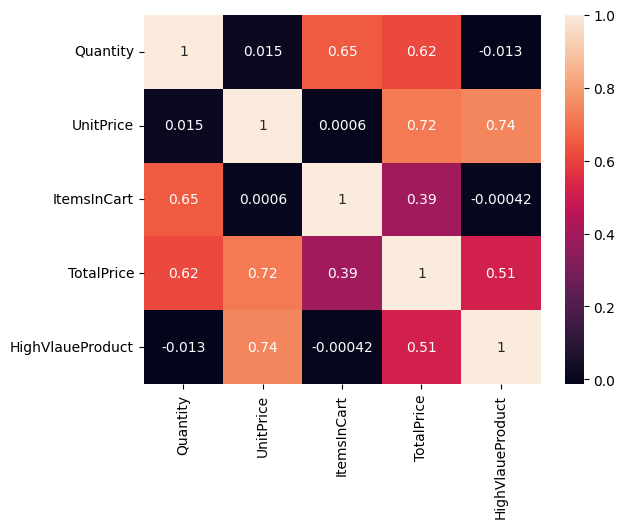

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)

In [ ]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'HighVlaueProduct', 'WeekendOrders', 'WeekdayOrders'],
      dtype='object')

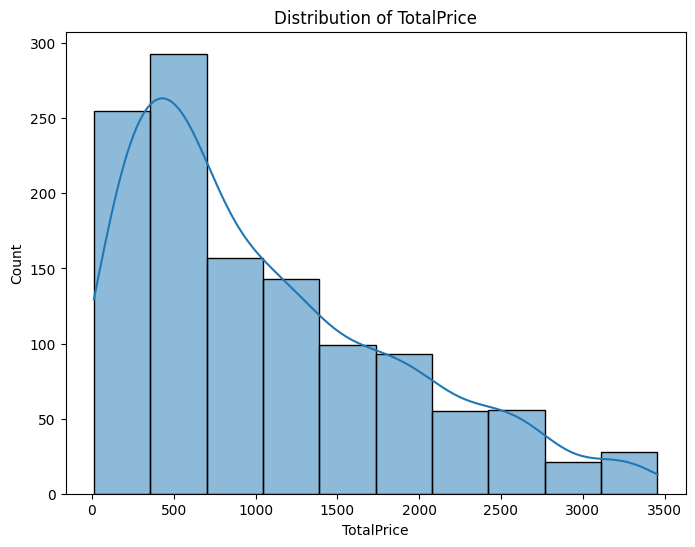

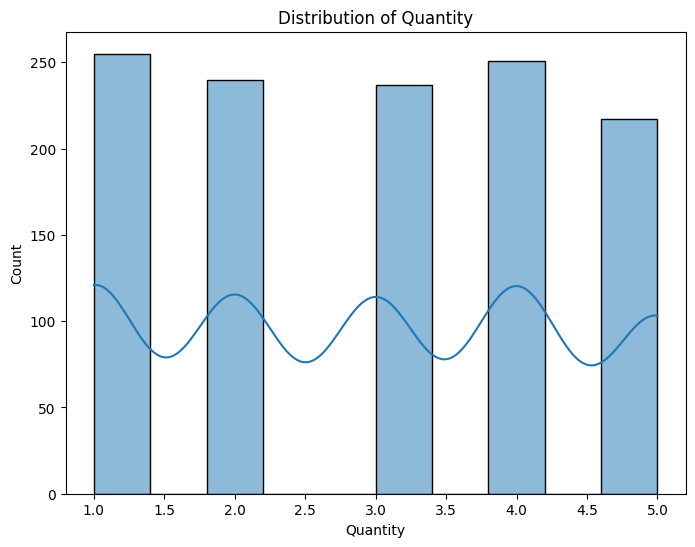

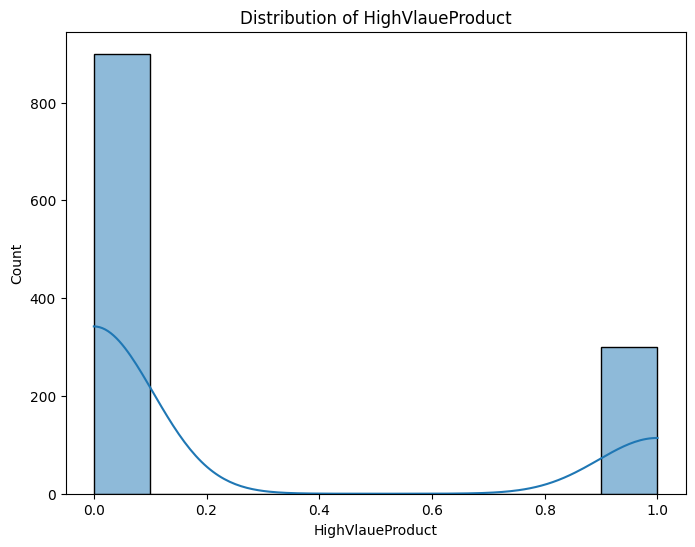

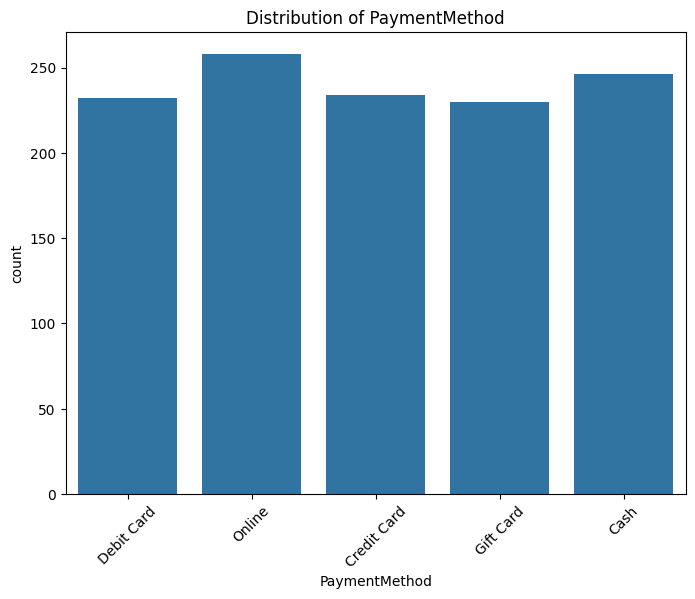

In [ ]:
numerical_cols = ['TotalPrice', 'Quantity', 'HighVlaueProduct']
categorical_cols = ['PaymentMethod']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, bins=10, kde= True)
    plt.title(f'Distribution of {col}')
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()